# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |  Emilio Navarro |
| **Fecha**      | 05-03-2026  |
| **Expediente** |  757955 | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("Default.csv")

In [48]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [49]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [50]:
df.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880
5,No,Yes,919.588531,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451340
8,No,No,1161.057854,37468.529290
9,No,No,0.000000,29275.268290


In [51]:
df.head(15)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880
5,No,Yes,919.588531,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451340
8,No,No,1161.057854,37468.529290
9,No,No,0.000000,29275.268290


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [52]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [53]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


In [54]:
df.describe(include="all")

,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729275


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Las columnas que hay son default, student, balance y income

Las columnas de balance y income son datos numericos, en describe nos dice su media, minimo, desviacion, etc

Las columnas de deafult y student son datos categoricos y sus valores son yes y no

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [55]:
df["default"] = df["default"].astype("category")

In [56]:
df["student"] = df["student"].astype("category")

In [57]:
df.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

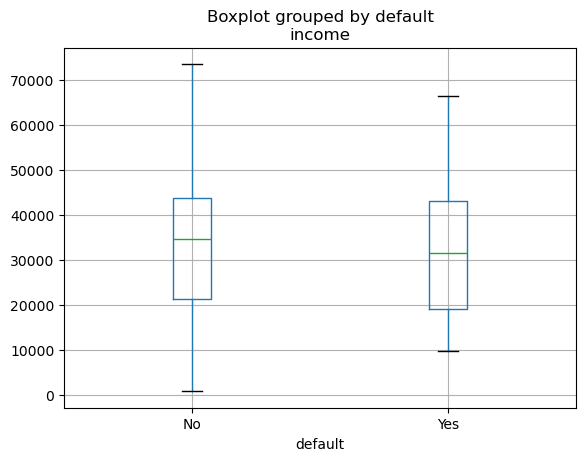

In [58]:
df.boxplot(column="income", by="default")
plt.show()

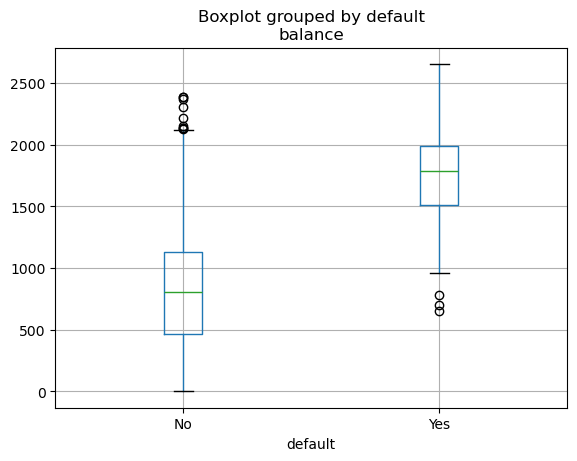

In [59]:
df.boxplot(column="balance", by="default")
plt.show()

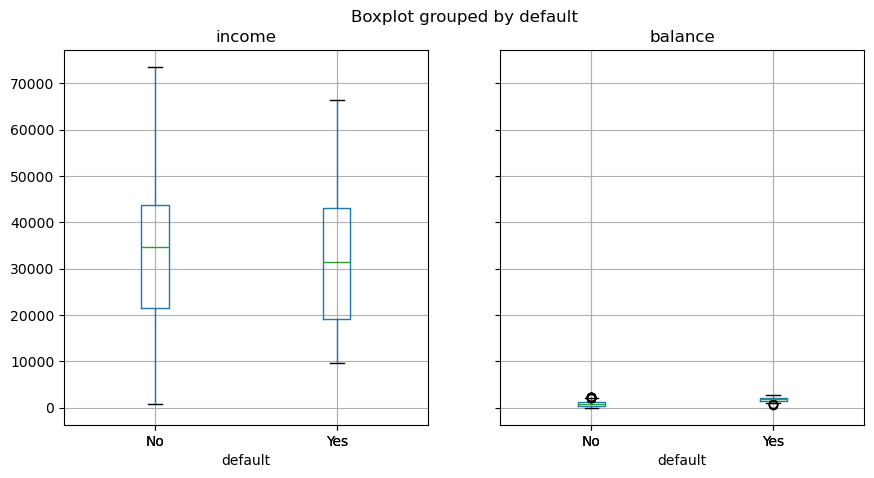

In [60]:
df.boxplot(column=["income", "balance"], by="default", figsize=(10,5))
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

In [61]:
df["default_num"] = df["default"].map({"No": 0, "Yes": 1})
df["default_num"].head()

0    0
1    0
2    0
3    0
4    0
Name: default_num, dtype: category
Categories (2, int64): [0, 1]

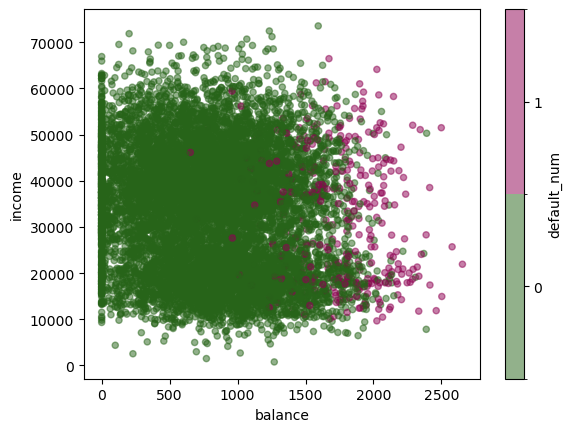

In [62]:
df.plot.scatter(x="balance", y="income", c="default_num", colormap="PiYG_r", alpha=0.5)
plt.show()

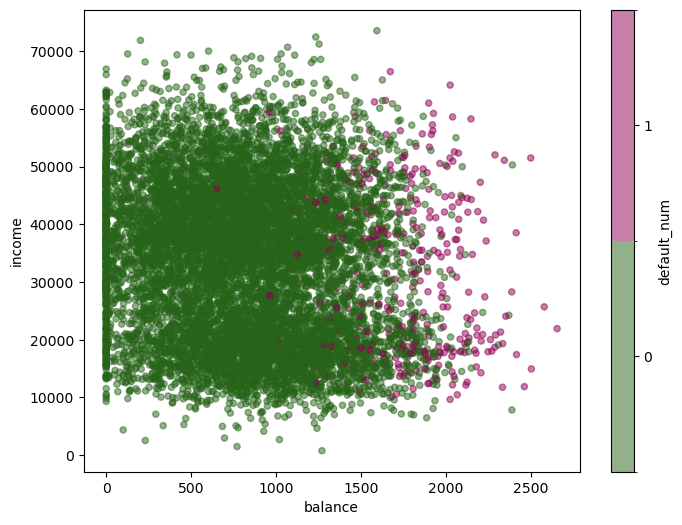

In [63]:
df.plot.scatter(x="balance", y="income", c="default_num", colormap="PiYG_r", alpha=0.5, figsize=(8,6))
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [64]:
y = df["default"] == "Yes"
y.head()

0    False
1    False
2    False
3    False
4    False
Name: default, dtype: bool

In [65]:
x = df["balance"]
x.head()

0     729.526495
1     817.180407
2    1073.549164
3     529.250605
4     785.655883
Name: balance, dtype: float64

In [66]:
print(y.head())
print(x.head())

0    False
1    False
2    False
3    False
4    False
Name: default, dtype: bool
0     729.526495
1     817.180407
2    1073.549164
3     529.250605
4     785.655883
Name: balance, dtype: float64


Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

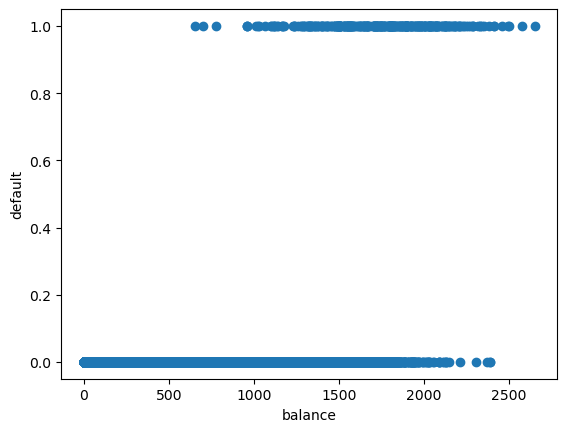

In [67]:
plt.scatter(x, y)
plt.xlabel("balance")
plt.ylabel("default")
plt.show()

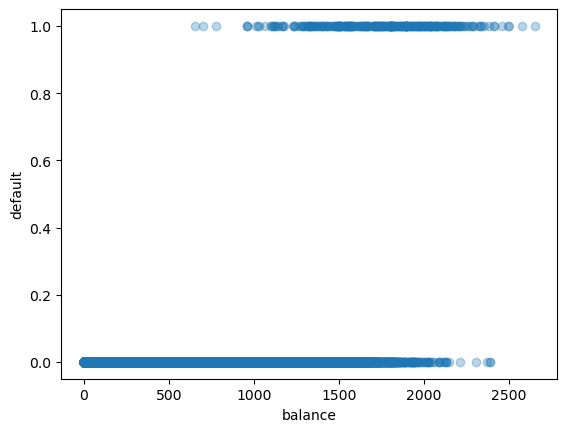

In [68]:
plt.scatter(x, y, alpha=0.3)
plt.xlabel("balance")
plt.ylabel("default")
plt.show()

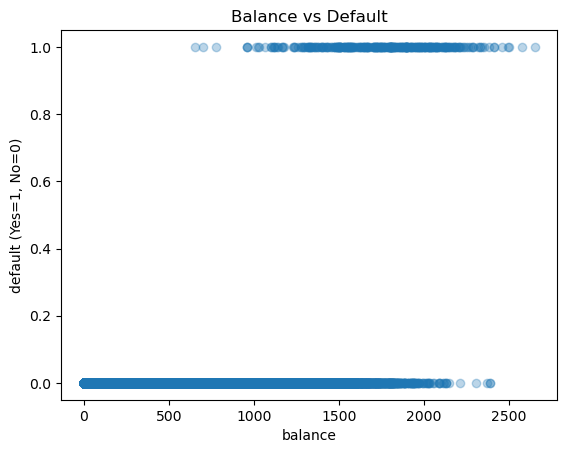

In [69]:
plt.scatter(x, y, alpha=0.3)
plt.xlabel("balance")
plt.ylabel("default (Yes=1, No=0)")
plt.title("Balance vs Default")
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
modelo = LogisticRegression()
modelo.fit(x.to_frame(), y)

LogisticRegression()

In [73]:
print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_)

Intercepto: [-10.65132824]
Coeficiente: [[0.00549892]]


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [74]:
beta0 = modelo.intercept_[0]
beta1 = modelo.coef_[0][0]

print(beta0, beta1)

-10.651328236144847 0.005498915546890769


In [75]:
z = beta0 + beta1 * x
z.head()

0   -6.639724
1   -6.157722
2   -4.747972
3   -7.741024
4   -6.331073
Name: balance, dtype: float64

In [76]:
p = 1 / (1 + np.exp(-z))
p.head()

0    0.001306
1    0.002113
2    0.008595
3    0.000434
4    0.001777
Name: balance, dtype: float64

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [77]:
incertidumbre = p * (1 - p)
incertidumbre.head()

0    0.001304
1    0.002108
2    0.008521
3    0.000434
4    0.001774
Name: balance, dtype: float64

In [78]:
incertidumbre.describe()

count    10000.000000
mean         0.021720
std          0.048846
min          0.000024
25%          0.000334
50%          0.002184
75%          0.014030
max          0.249998
Name: balance, dtype: float64

In [79]:
print(incertidumbre.head())
print(incertidumbre.max())

0    0.001304
1    0.002108
2    0.008521
3    0.000434
4    0.001774
Name: balance, dtype: float64
0.24999838230061197


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [80]:
V = np.diagflat(p * (1 - p))

In [81]:
V.shape

(10000, 10000)

In [82]:
V[:5, :5]

array([[0.00130398, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.00210813, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.00852088, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.00043425, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.0017738 ]])

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [83]:
X = np.column_stack((np.ones(len(x)), x))
X[:5]

array([[1.00000000e+00, 7.29526495e+02],
       [1.00000000e+00, 8.17180407e+02],
       [1.00000000e+00, 1.07354916e+03],
       [1.00000000e+00, 5.29250605e+02],
       [1.00000000e+00, 7.85655883e+02]])

In [84]:
cov = np.linalg.inv(X.T @ V @ X)
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

In [85]:
cov.shape

(2, 2)

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [86]:
se = np.sqrt(np.diag(cov))
se

array([3.61168600e-01, 2.20376169e-04])

In [87]:
print("SE beta0:", se[0])
print("SE beta1:", se[1])

SE beta0: 0.361168599715068
SE beta1: 0.00022037616946188714


In [88]:
pd.DataFrame({
    "Parametro": ["beta0", "beta1"],
    "SE": se
})

,Parametro,SE
0,beta0,0.361169
1,beta1,0.000220


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [89]:
betas = np.array([beta0, beta1])
betas

array([-1.06513282e+01,  5.49891555e-03])

In [90]:
z = betas / se
z

array([-29.49129089,  24.95240552])

In [91]:
pd.DataFrame({
    "Parametro": ["beta0", "beta1"],
    "Beta": betas,
    "SE": se,
    "z": z
})

,Parametro,Beta,SE,z
0,beta0,-10.651328,0.361169,-29.491291
1,beta1,0.005499,0.000220,24.952406


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [92]:
from scipy.stats import norm

In [93]:
p_value = 2 * (1 - norm.cdf(abs(z)))
p_value

array([0., 0.])

In [94]:
pd.DataFrame({
    "Parametro": ["beta0", "beta1"],
    "z": z,
    "p_value": p_value
})

,Parametro,z,p_value
0,beta0,-29.491291,0.0
1,beta1,24.952406,0.0


¿Es significativa la relación de los factores con la variable de respuesta?

La relación entre balance y default es estadísticamente significativa si el p-value es menor que 0.05.

El p-value es muy pequeño, hace que el balance tiene una relación significativa con la probabilidad de que una persona caiga en default.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [95]:
y2 = (df["default"] == "Yes")
x2 = (df["student"] == "Yes").astype(int)

from sklearn.linear_model import LogisticRegression
modelo2 = LogisticRegression()
modelo2.fit(x2.to_frame(), y2)

beta0_2 = modelo2.intercept_[0]
beta1_2 = modelo2.coef_[0][0]

print("beta0:", beta0_2)
print("beta1:", beta1_2)

beta0: -3.5025724918531327
beta1: 0.3962088847686546


In [96]:
p2 = modelo2.predict_proba(x2.to_frame())[:, 1]
V2 = np.diagflat(p2 * (1 - p2))

X2 = np.column_stack((np.ones(len(x2)), x2))
cov2 = np.linalg.inv(X2.T @ V2 @ X2)
se2 = np.sqrt(np.diag(cov2))

print("SE beta0:", se2[0])
print("SE beta1:", se2[1])

SE beta0: 0.07066142671068852
SE beta1: 0.11522061447776838


In [97]:
z2 = np.array([beta0_2, beta1_2]) / se2
p_value2 = 2 * (1 - norm.cdf(abs(z2)))

pd.DataFrame({
    "Parametro": ["beta0", "beta1_student"],
    "Beta": [beta0_2, beta1_2],
    "SE": se2,
    "z": z2,
    "p_value": p_value2
})

,Parametro,Beta,SE,z,p_value
0,beta0,-3.502572,0.070661,-49.568381,0.000000
1,beta1_student,0.396209,0.115221,3.438698,0.000585


## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [98]:
y3 = (df["default"] == "Yes").astype(int)

X3 = pd.DataFrame({
    "balance": df["balance"],
    "income": df["income"],
    "student": (df["student"] == "Yes").astype(int)
})

modelo3 = LogisticRegression()
modelo3.fit(X3, y3)

beta3 = np.concatenate([modelo3.intercept_, modelo3.coef_[0]])
print(beta3)

[-1.09017901e+01  5.73059539e-03  3.96182665e-06 -6.12573924e-01]


In [99]:
p3 = modelo3.predict_proba(X3)[:, 1]
V3 = np.diagflat(p3 * (1 - p3))

X3_mat = np.column_stack((np.ones(len(X3)), X3))
cov3 = np.linalg.inv(X3_mat.T @ V3 @ X3_mat)
se3 = np.sqrt(np.diag(cov3))

print(se3)

[4.93157600e-01 2.31674957e-04 8.20843571e-06 2.36393842e-01]


In [100]:
z3 = beta3 / se3
p_value3 = 2 * (1 - norm.cdf(abs(z3)))

pd.DataFrame({
    "Parametro": ["beta0", "balance", "income", "student"],
    "Beta": beta3,
    "SE": se3,
    "z": z3,
    "p_value": p_value3
})

,Parametro,Beta,SE,z,p_value
0,beta0,-10.901790,0.493158,-22.106098,0.000000
1,balance,0.005731,0.000232,24.735498,0.000000
2,income,0.000004,0.000008,0.482653,0.629342
3,student,-0.612574,0.236394,-2.591328,0.009561


¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

Spam de los mails, el falso positivo es que un correo donde sea importante lo marque de spam, se pierde informacion

Sistemas de seguridad de aeropuertos, el falso positivo es que una persona sea marcada sospechosa el cual no lo es, esto hace a que hayan revisiones inecesearias

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

Los fraudes bancarios, el falso negativo seria que no detecte una transaccion rara y esto genera perdidas y confianza

Deteccion de lavado de dinero el falso negativo es cuando hay un deposito sospechoso, el sistema lo clasifica normal, hace que se permitan actividades ilegales

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3